In [50]:
import os 

import torch
import pandas as pd 
import numpy as np
import cv2
import sqlite3
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from pathlib import Path

ROOT = Path.cwd().parents[1]

IMAGE_DIR = ROOT / "images/emb_visuals"

In [51]:
os.makedirs(IMAGE_DIR, exist_ok=True)

In [21]:
embeds = torch.load(ROOT / "data/embeddings/base_embeds.pt", weights_only=False)
cls_tokens = embeds["cls_tokens"]
patches = embeds["patches"]

conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)
categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)
types_per_cat = pd.read_sql_query("""
    SELECT category, COUNT(DISTINCT type) AS num_types
    FROM meta
    GROUP BY category
""", conn)
max_types = types_per_cat["num_types"].max()

conn.close()

In [44]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2)
umap = UMAP(n_components=2, random_state=42)

c:\Projects\UL-Summer-Bursary-2026\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


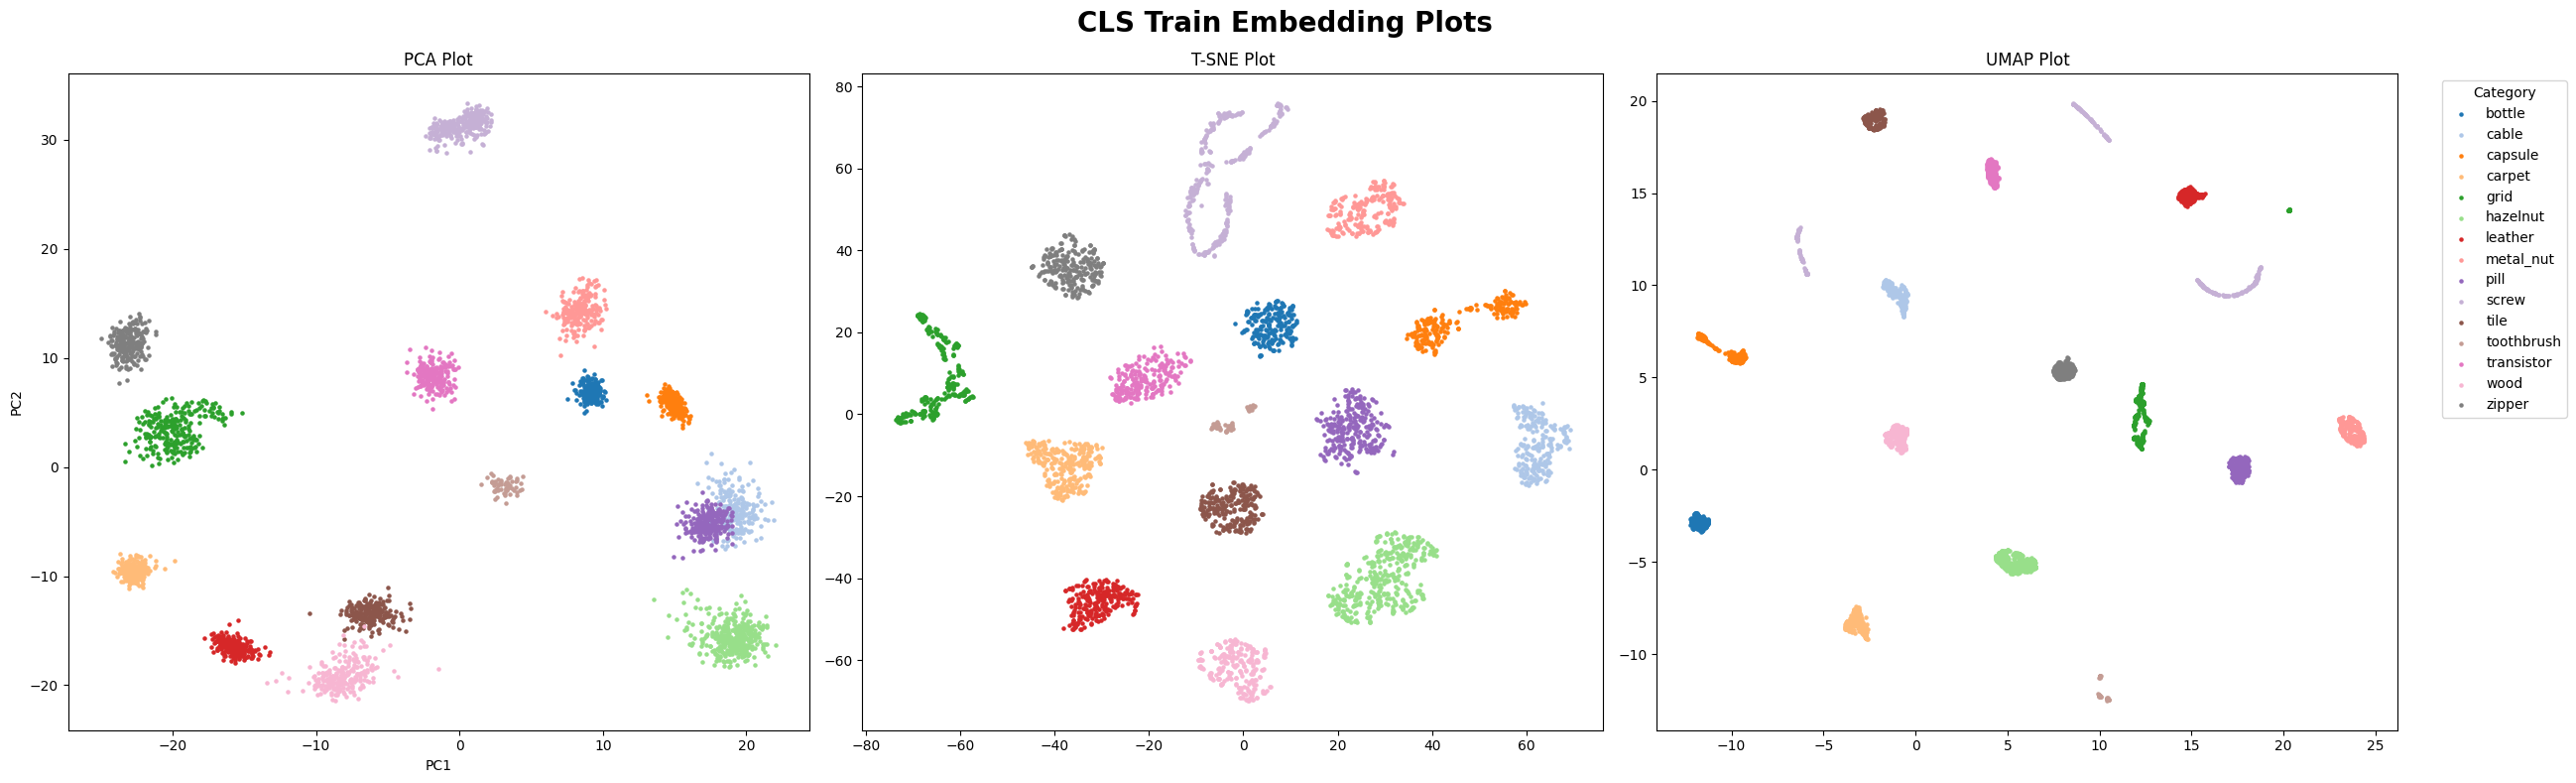

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

cls_pca_2d = pca.fit_transform(cls_tokens)
cls_tsne_2d = tsne.fit_transform(cls_tokens)
cls_umap_2d = umap.fit_transform(cls_tokens)

categories = sorted(meta["category"].unique())
colors = list(plt.cm.tab20.colors[:len(categories)])

axes[0].set_title("PCA Plot")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].set_title("T-SNE Plot")

axes[2].set_title("UMAP Plot")

for color, category in zip(colors, categories):
    mask = (
        (meta["category"] == category) & (meta["split"] == "train")
    )

    axes[0].scatter(
        cls_pca_2d[mask, 0],
        cls_pca_2d[mask, 1],
        s=5,
        color=color,
        label=category
    )

    axes[1].scatter(
        cls_tsne_2d[mask, 0],
        cls_tsne_2d[mask, 1],
        s=5,
        color=color,
        label=category
    )

    axes[2].scatter(
        cls_umap_2d[mask, 0],
        cls_umap_2d[mask, 1],
        s=5,
        color=color,
        label=category
    )

fig.suptitle(
    "CLS Train Embedding Plots",
    fontsize=20,
    fontweight="bold"
)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(f"{IMAGE_DIR}/CLS_plots.svg")
plt.show()

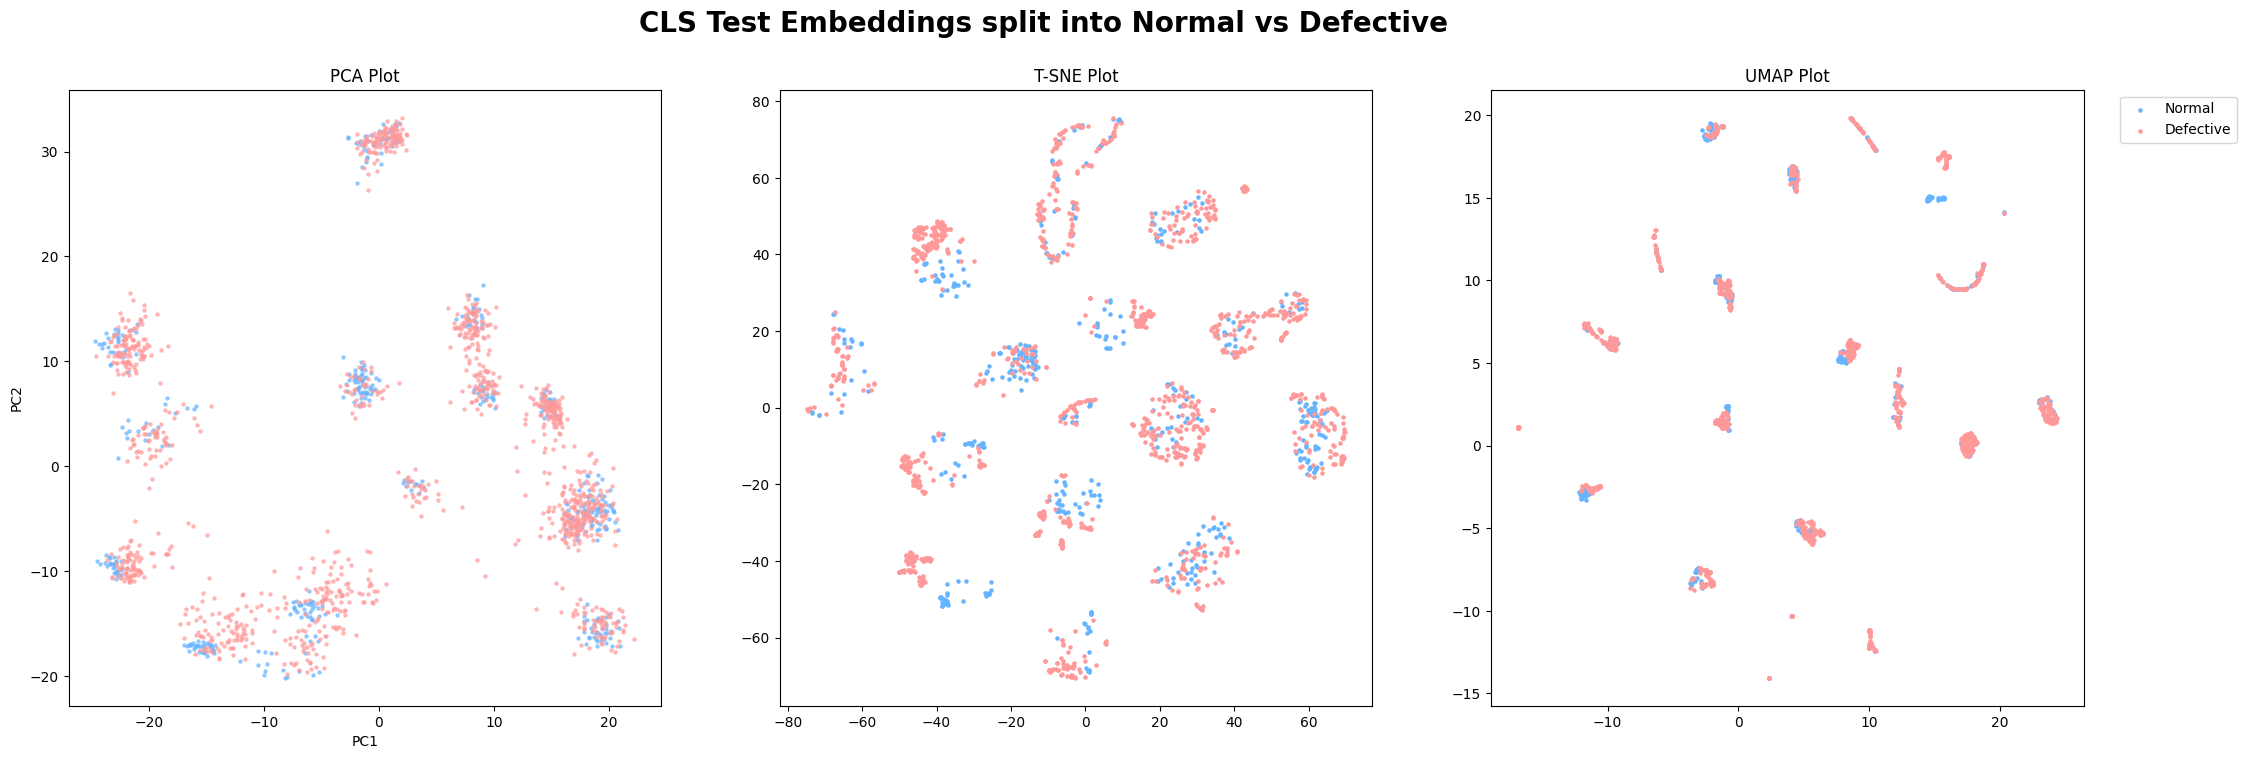

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

meta_data = [(0, "Normal", "#66b3ff"), (1, "Defective", "#ff9999")]

axes[0].set_title("PCA Plot")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].set_title("T-SNE Plot")

axes[2].set_title("UMAP Plot")

for label, name, color in meta_data:
    
    mask = ((meta["split"] == "test") & (meta["label"] == label))

    axes[0].scatter(
        cls_pca_2d[mask, 0],
        cls_pca_2d[mask, 1],
        s=5,
        alpha=0.6,
        color=color,
        label=name
    )

    axes[1].scatter(
        cls_tsne_2d[mask, 0],
        cls_tsne_2d[mask, 1],
        s=5,
        color=color,
        label=category
    )

    axes[2].scatter(
        cls_umap_2d[mask, 0],
        cls_umap_2d[mask, 1],
        s=5,
        color=color,
        label=name
    )

fig.suptitle(
    "CLS Test Embeddings split into Normal vs Defective",
    fontsize=20,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.savefig(f"{IMAGE_DIR}/CLS_defects.svg")
plt.show()

bottle good 256 0
bottle broken_large 256 45
bottle broken_small 256 12
bottle contamination 256 54
cable good 256 0
cable bent_wire 256 58
cable cable_swap 256 30
cable combined 256 40
cable cut_inner_insulation 256 34
cable cut_outer_insulation 256 10
cable missing_cable 256 26
cable missing_wire 256 13
cable poke_insulation 256 17
capsule good 256 0
capsule crack 256 8
capsule faulty_imprint 256 3
capsule poke 256 2
capsule scratch 256 9
capsule squeeze 256 18
carpet good 256 0
carpet color 256 24
carpet cut 256 21
carpet hole 256 8
carpet metal_contamination 256 6
carpet thread 256 5
grid good 256 0
grid bent 256 19
grid broken 256 11
grid glue 256 5
grid metal_contamination 256 4
grid thread 256 8
hazelnut good 256 0
hazelnut crack 256 31
hazelnut cut 256 7
hazelnut hole 256 6
hazelnut print 256 15
leather good 256 0
leather color 256 4
leather cut 256 11
leather fold 256 8
leather glue 256 6
leather poke 256 4
metal_nut good 256 0
metal_nut bent 256 12
metal_nut color 256 10
meta

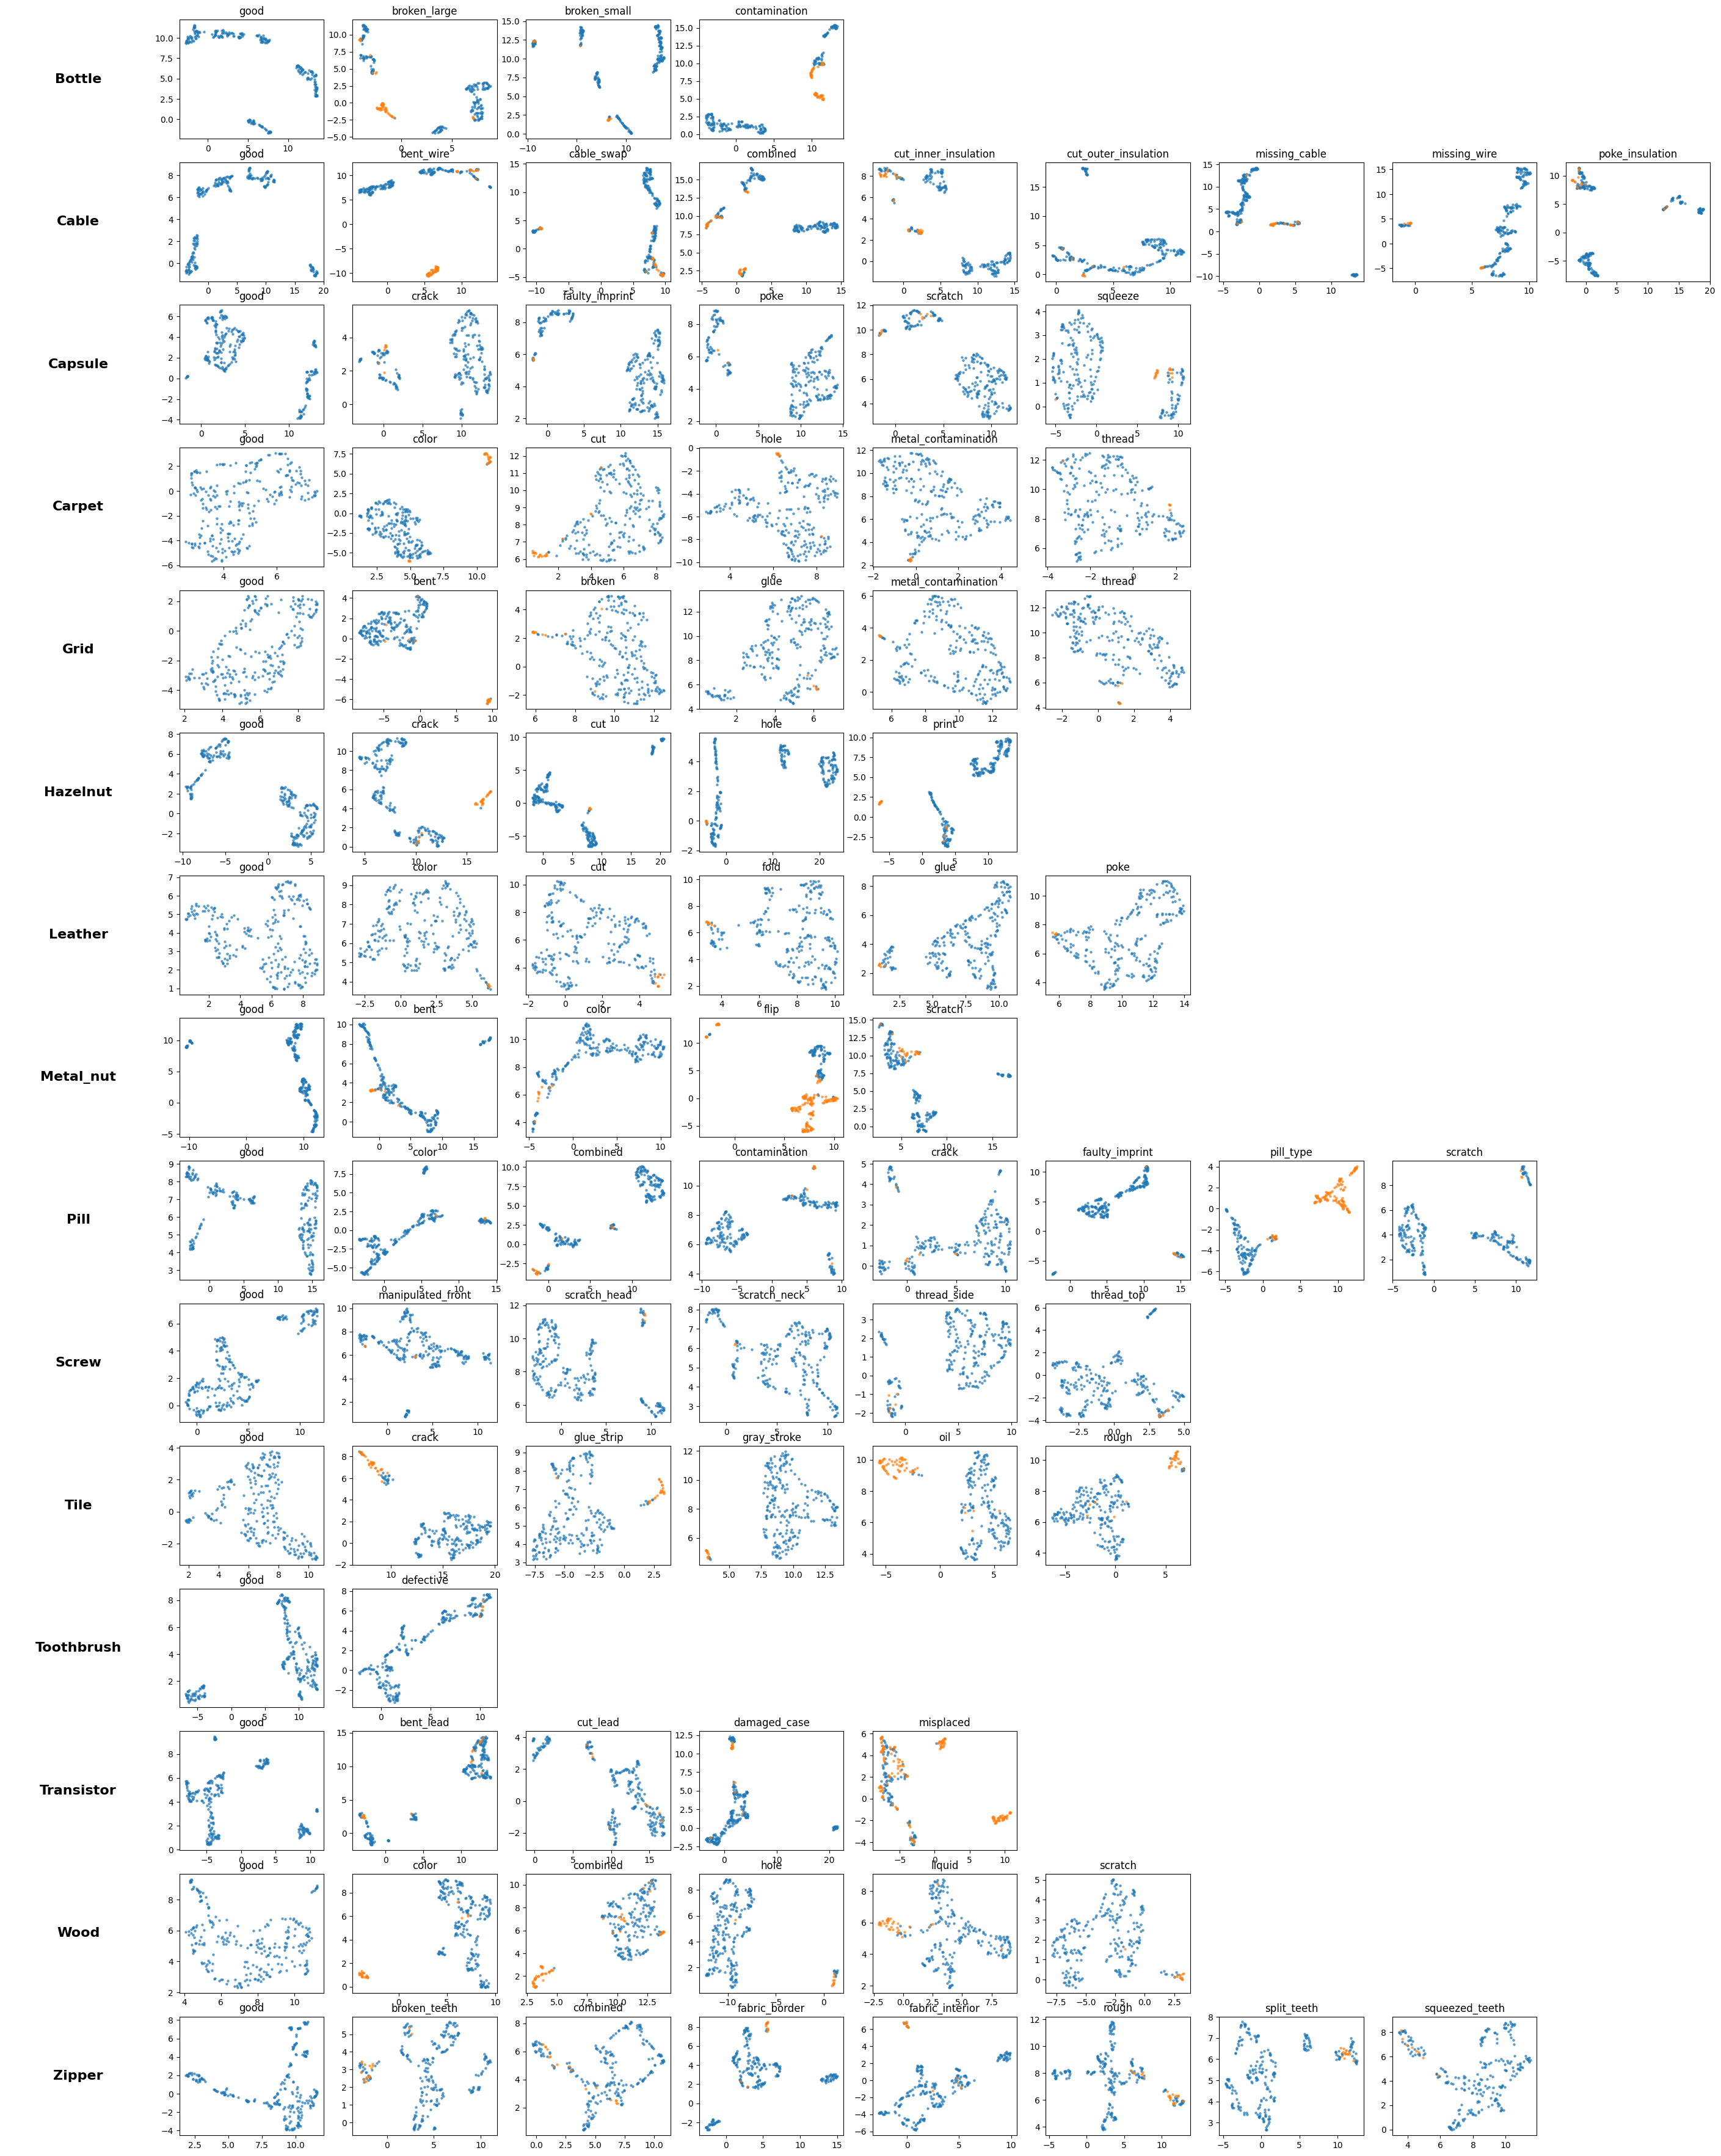

In [ ]:
patch_size = 14

fig, axes = plt.subplots(
    len(categories),
    max_types + 1,
    figsize=(4 * max_types, 3 * len(categories))
)

for row, cat in enumerate(categories):
    test_samples = (
        meta[
            (meta["category"] == cat)
            & (meta["split"] == "test")
        ]
        .groupby("type", group_keys=False)
        .sample(n=1, random_state=42)
    )

    test_samples = test_samples.sort_values("type", key=lambda s: s.map(lambda x: (x != "good", x)))

    axes[row, 0].text(
    0.5,
    0.5,
    cat.capitalize(),
    fontsize=16,
    fontweight="bold",
    ha="center",
    va="center"
    )

    axes[row, 0].axis("off")

    for col, (idx, record) in enumerate(test_samples.iterrows(), start=1):
        ax = axes[row, col]

        patch_labels = []

        path = str(ROOT / record["path"])

        if record["type"] == "good":
            patch_labels = [0] * 256
            
        else:
            mask_path = path.replace("\\test\\", "\\ground_truth\\").replace(".png", "_mask.png")

            mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask_img = cv2.resize(
                mask_img,
                (224, 224),
                interpolation=cv2.INTER_NEAREST
            )

            for y in range(0, 224, patch_size):
                for x in range(0, 224, patch_size):
                    patch = mask_img[y:y+14, x:x+14]
                    patch_labels.append(int(np.any(patch > 0)))
        
        patch_labels = np.array(patch_labels, dtype=bool)
        patches_2d = umap.fit_transform(patches[idx])

        ax.set_title(record["type"])
        ax.scatter(
            patches_2d[~patch_labels, 0],
            patches_2d[~patch_labels, 1],
            s=5,
            alpha=0.6,
            label="Normal"
        )

        ax.scatter(
            patches_2d[patch_labels, 0],
            patches_2d[patch_labels, 1],
            s=5,
            alpha=0.6,
            label="Anomalous"
        )
        
        print(record["category"], record["type"], len(patch_labels), sum(patch_labels))
        
    for col in range(len(test_samples)+1, max_types+1):
        axes[row, col].axis("off")

plt.savefig(f"{IMAGE_DIR}/patch_defects.svg")
plt.show()
